# Imports

In [1]:
import math
import json
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import sys
from typing import List, Dict
from pypalettes import load_palette
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[1] / "src"))

from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.riczne import RichardsonZne
from nbutils.lsf_zne_hill import *
from nbutils.data_loader import load_all_experiments

from nbutils.lsf_zne import *
import nbutils.rtc_fitting as rtc 

### `load_all_experiments`

In [2]:
# ==========================================
# Recursive experiment loader
# ==========================================

def load_all_experiments(data_root):
    """
    Recursively load all experiments under data_root and
    populate a master data_records dictionary.

    Parameters
    ----------
    data_root : str or Path
        Root directory containing experiment folders (e.g. data/)

    Returns
    -------
    data_records : dict
        Master experiment registry
    """
    data_root = Path(data_root)
    data_records = {}

    # Iterate over subdirectories like c0, c0.01, ...
    for exp_dir in sorted(p for p in data_root.iterdir() if p.is_dir()):
        experiment_id = exp_dir.name

        json_files = sorted(exp_dir.rglob("iter_*.json"))
        if not json_files:
            continue  # skip empty folders

        # --------------------------
        # Load and group raw data
        # --------------------------
        raw_groups = {}
        exact_solution = None

        for jf in json_files:
            with open(jf, "r") as f:
                data = json.load(f)

            t_max = data["config"]["ansatz"]["ugate"]["time"]["max"]
            cost = data["output"]["optimized_minimum_cost"][0]

            if exact_solution is None:
                exact_solution = data["output"].get("exact_sol", None)

            raw_groups.setdefault(t_max, []).append(cost)

        # --------------------------
        # Processed arrays
        # --------------------------
        t_vals = np.array(sorted(raw_groups.keys()))
        vqe_means = np.array([np.mean(raw_groups[t]) for t in t_vals])
        vqe_stds = np.array([np.std(raw_groups[t]) for t in t_vals])

        # --------------------------
        # Register experiment
        # --------------------------
        data_records[experiment_id] = {
            "meta": {
                "experiment_id": experiment_id,
                "data_path": str(exp_dir),
                "num_json_files": len(json_files),
                "noise_level": float(experiment_id.replace("c", "")) if experiment_id.startswith("c") else None,
            },

            "raw": {
                "json_files": [str(f) for f in json_files],
                "grouped_costs": raw_groups,
            },

            "processed": {
                "t_max": t_vals,
                "vqe_means": vqe_means,
                "vqe_stds": vqe_stds,
                "exact_solution": exact_solution,
            },

        }

    return data_records

In [4]:
data_records_obs_ising = load_all_experiments("data")

In [11]:
vqe_means_by_c_ising = {}
vqe_stds_by_c_ising = {}
t_vals_by_c_ising = {}
EXACT_SOLUTION_ising = data_records_obs_ising["c0"]["processed"]["exact_solution"]
data_root = Path("data")

for c_dir in sorted(data_root.glob("c*")):
    # skip non-directories just in case
    if not c_dir.is_dir():
        continue

    # extract numeric C value: "c0.022" -> 0.022
    c = float(c_dir.name[1:])
    #print(f"Dir: c_dir.name")
    record = data_records_obs_ising[c_dir.name]["processed"]

    vqe_means_by_c_ising[c] = record["vqe_means"]
    vqe_stds_by_c_ising[c] = record["vqe_stds"]
    t_vals_by_c_ising[c] = record["t_max"]
print(f"Exact solution with ising: {EXACT_SOLUTION_ising}")

Exact solution with ising: -6.026674183332271


Plotting VQE costs vs $T_{max}$ across different values of $C$

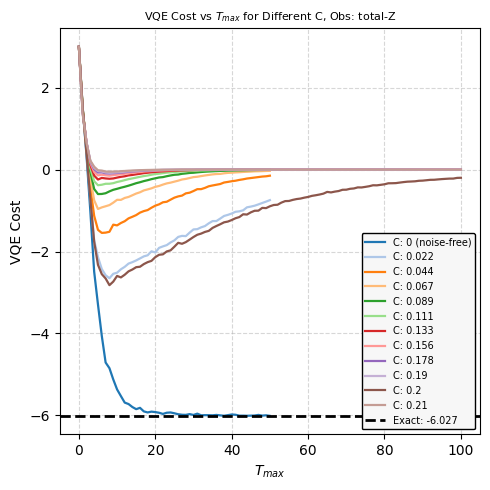

In [14]:
plt.figure(figsize=(5, 5))

# Filter for the specific target values of C
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111,
               0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
Cs = [c for c in target_vals if c in vqe_means_by_c_ising]

# Use tab20 for >10 curves (high contrast, discrete)
colors = plt.cm.tab20.colors[:len(Cs)]

for c, color in zip(Cs, colors):
    label = "C: 0 (noise-free)" if np.isclose(c, 0.0) else f"C: {c:g}"
    plt.plot(
        t_vals_by_c_ising[c],
        vqe_means_by_c_ising[c],
        linewidth=1.6,
        alpha=1.0,
        color=color,
        label=label
    )

# Exact line (black is better than red for papers)
plt.axhline(
    y=EXACT_SOLUTION_ising,
    linestyle='--',
    linewidth=2.0,
    color='black',
    label=f'Exact: {EXACT_SOLUTION_ising:.3f}'
)

plt.xlabel("$T_{max}$")
plt.ylabel("VQE Cost")
plt.title("VQE Cost vs $T_{max}$ for Different C, Obs: total-Z", fontsize=8)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(
    loc="lower right",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='#f7f7f7',
    framealpha=1
)

plt.tight_layout()
plt.show()


In [16]:
# Reference energy at C=0
E0 = np.array(vqe_means_by_c_ising[0], dtype=float)
T0 = np.array(t_vals_by_c_ising[0], dtype=float)

plt.figure()

for c in sorted(vqe_means_by_c_ising.keys()):
    if c == 0.0:
        continue

    E_c = np.array(vqe_means_by_c_ising[c], dtype=float)
    T_c = np.array(t_vals_by_c_ising[c], dtype=float)

    # Ensure time grids align
    if not np.allclose(T_c, T0):
        print(f"Warning: T grids differ for C={c}")
        continue

    ratio = E_c / E0

    # Masks
    positive_mask = ratio > 0
    nonpositive_mask = ratio <= 0

    # Report invalid points
    if np.any(nonpositive_mask):
        print(f"C={c}: non-positive ratio at")
        print("  T =", T_c[nonpositive_mask])
        print("  ratio =", ratio[nonpositive_mask])

    # Compute R only where valid
    R = np.full(ratio.shape, np.nan, dtype=float)
    R[positive_mask] = -np.log(ratio[positive_mask])

    # Plot valid curve
    plt.plot(T_c, R, label=f"C={c}")

    # Highlight invalid (ratio ≤ 0) points
    if np.any(nonpositive_mask):
        plt.scatter(
            T_c[nonpositive_mask],
            np.zeros_like(T_c[nonpositive_mask]),
            marker="x",
            color="red",
            zorder=3,
            label="ratio ≤ 0" if c == sorted(vqe_means_by_c_ising.keys())[1] else None
        )

plt.grid()
plt.xlabel(r"$T_{\max}$")
plt.ylabel(r"$R(T, C)$")
plt.title(r"$R(T, C) = -\log(E(T,C)/E(T,C=0))$")
plt.legend()
plt.show()

ValueError: operands could not be broadcast together with shapes (101,) (51,) 

<Figure size 640x480 with 0 Axes>